In [1]:
import torch


def rbf_kernel(X1, X2, lengthscale, variance=1.0):
    """
    Computes the RBF kernel matrix with ARD support.

    Args:
        X1 (torch.Tensor): A tensor of size (N, D).
        X2 (torch.Tensor): A tensor of size (M, D).
        lengthscale (torch.Tensor): A tensor of size (D,) representing the lengthscale for each dimension.
        variance (float): The kernel variance.
    """
    # Ensure variance is a tensor on the correct device
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    
    # Scale each dimension of X1 and X2 by the corresponding lengthscale
    # This uses broadcasting to efficiently perform the operation
    X1_scaled = X1 / lengthscale
    X2_scaled = X2 / lengthscale
    
    # Compute the squared Euclidean distance in the scaled space
    sqdist = torch.cdist(X1_scaled, X2_scaled, p=2).pow(2)
    
    return variance * torch.exp(-0.5 * sqdist)


def matern52_kernel(X1, X2, lengthscale, variance=1.0):
    sqdist = torch.cdist(X1 / lengthscale, X2 / lengthscale, p=2)
    term1 = 1 + torch.sqrt(5) * sqdist + (5/3) * sqdist**2
    term2 = torch.exp(-torch.sqrt(5) * sqdist)
    return variance * term1 * term2


import torch

# --- Helper class for Priors ---
class GammaPrior:
    def __init__(self, concentration, rate):
        self.concentration = concentration
        self.rate = rate

    def log_prob(self, x):
        # Log probability density of Gamma distribution (constants omitted)
        return (self.concentration - 1.0) * torch.log(x.clamp(min=1e-9)) - self.rate * x

class LogNormalPrior:
    def __init__(self, loc, scale):
        self.loc = loc
        self.scale = scale
        self.var = scale**2

    def log_prob(self, x):
        # Log probability density of LogNormal distribution (constants omitted)
        log_x = torch.log(x.clamp(min=1e-9))
        return -log_x - (log_x - self.loc)**2 / (2 * self.var)

In [ ]:
# from .kernels import rbf_kernel
# from .priors import GammaPrior, LogNormalPrior
import torch
import torch.nn as nn
import torch.optim as optim
import math
from torch.utils.data import DataLoader, TensorDataset
import logging


class SparseTPRTMiniBatch:
    """
    Implementation of Variational EM for Student-t Process Regression with Mini-batching.
    - E-Step: CAVI updates for variational parameters.
    - M-Step: Gradient-based optimization of model hyperparameters and inducing points
              using a stochastic estimate of the ELBO.
    """
    def __init__(self, X, y, M, nu_f=2.1, nu_e=2.1, kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=1.0):
        """
        Args:
            X (torch.Tensor): Full training inputs, shape (N, D).
            y (torch.Tensor): Full training outputs, shape (N, 1) or (N,).
            M (int): Number of inducing points.
            ... (hyperparameters)
        """
        self.X_full = X # Keep full data for reference (e.g., initialization)
        self.y_full = y.view(-1, 1) # Keep full data for reference
        self.N, self.D = X.shape
        self.M = M

        # --- Initialize Inducing Points using Sobol sequence from the full dataset ---
        Z_initial = self._initialize_inducing_points()
        self.Z = nn.Parameter(Z_initial)

        # --- Initialize Hyperparameters (M-step) ---
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f, dtype=X.dtype)))
        self.log_nu_epsilon = nn.Parameter(torch.log(torch.tensor(nu_e, dtype=X.dtype)))
        self.log_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2, dtype=X.dtype)))
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale, dtype=X.dtype)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=X.dtype)))

        # --- Initialize Priors for Hyperparameters ---
        self.lengthscale_prior = GammaPrior(3.0, 6.0)
        self.variance_prior = GammaPrior(2.0, 0.15)
        self.sigma_sq_prior = GammaPrior(1.1, 0.05)
        self.nu_prior = LogNormalPrior(loc=1.0, scale=1.0)

        # --- Initialize GLOBAL Variational Parameters (updated across batches) ---
        # Standard parameters (kept for compatibility with other functions like ELBO)
        self.m_u = torch.zeros(self.M, 1, dtype=X.dtype, device=X.device)
        self.S_u = torch.eye(self.M, dtype=X.dtype, device=X.device)
        self.alpha_r = torch.tensor(1.0, dtype=X.dtype, device=X.device)
        self.beta_r = torch.tensor(1.0, dtype=X.dtype, device=X.device)
        
        #################################################
        # MODIFICATION START: Natural Parameter Storage #
        #################################################
        # We store global variational parameters in their natural form for SVI.
        
        # Natural parameters for q(r) ~ Gamma(alpha, beta): η = (alpha - 1, -beta)
        self.eta_r1 = self.alpha_r - 1.0
        self.eta_r2 = -self.beta_r

        # Natural parameters for q(u) ~ N(m, S): η = (S⁻¹m, -0.5 * S⁻¹)
        S_u_inv = torch.linalg.inv(self.S_u)
        self.eta_u1 = S_u_inv @ self.m_u
        self.eta_u2 = -0.5 * S_u_inv

        # SVI learning rate schedule parameters
        self.svi_iteration = 0
        self.svi_tau = 10.0   # Delay parameter, prevents overly large steps at the beginning
        self.svi_kappa = 0.9  # Forgetting rate, should be in (0.5, 1.0]
        ###############################################
        # MODIFICATION END: Natural Parameter Storage #
        ###############################################

    def _initialize_inducing_points(self):
        min_bounds = self.X_full.min(dim=0).values
        max_bounds = self.X_full.max(dim=0).values
        sobol_engine = torch.quasirandom.SobolEngine(dimension=self.D, scramble=True, seed=0)
        sobol_points_unit = sobol_engine.draw(self.M).to(self.X_full.dtype)
        return min_bounds + sobol_points_unit * (max_bounds - min_bounds)

    def _get_hyperparams(self):
        return {
            "nu_f": torch.exp(self.log_nu_f),
            "nu_epsilon": torch.exp(self.log_nu_epsilon),
            "sigma_sq": torch.exp(self.log_sigma_sq),
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance)
        }

    # === E-Step Methods (now operate on a batch) ===
    def _update_q_lambda(self, y_batch, params, L_ZZ, K_XZ_batch, K_ZX_batch, k_ii_batch):
        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        expected_f_mean = K_XZ_batch @ KZZ_inv_m_u # Shape: (B, 1)

        if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else: expected_r_inv = self.beta_r

        KXZ_KZZ_inv = torch.cholesky_solve(K_ZX_batch, L_ZZ).T
        var_f_term1 = expected_r_inv * (k_ii_batch - (KXZ_KZZ_inv * K_XZ_batch).sum(dim=1))
        var_f_term2 = (KXZ_KZZ_inv @ self.S_u * KXZ_KZZ_inv).sum(dim=1)
        var_f = (var_f_term1 + var_f_term2).unsqueeze(1) # Shape: (B, 1)

        expected_sq_error = (y_batch - expected_f_mean).pow(2) + var_f
        alpha_lambda_batch = params['nu_epsilon'] / 2.0 + 0.5
        beta_lambda_batch = params['nu_epsilon'] / 2.0 + (0.5 / params['sigma_sq']) * expected_sq_error
        return alpha_lambda_batch, beta_lambda_batch

    ################################################
    # MODIFICATION START: SVI Update for q(r)      #
    ################################################
    def _update_q_r(self, params, L_ZZ):
        # Calculate the expectation E[u^T K_ZZ^-1 u] needed for the update
        trace_term = torch.trace(torch.cholesky_solve(self.S_u, L_ZZ))
        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        mean_term = self.m_u.T @ KZZ_inv_m_u
        expected_u_quadratic_form = trace_term + mean_term

        # Calculate the target standard parameters for q(r) based on the current q(u)
        alpha_r_target = params['nu_f'] / 2.0 + self.M / 2.0
        beta_r_target = params['nu_f'] / 2.0 + 0.5 * expected_u_quadratic_form.squeeze()

        # Convert target standard parameters to natural parameters
        eta_r1_target = alpha_r_target - 1.0
        eta_r2_target = -beta_r_target

        # Get SVI learning rate
        rho = (self.svi_iteration + self.svi_tau)**(-self.svi_kappa)

        # Perform the stochastic update on the global natural parameters
        self.eta_r1 = (1.0 - rho) * self.eta_r1 + rho * eta_r1_target
        self.eta_r2 = (1.0 - rho) * self.eta_r2 + rho * eta_r2_target

        # Convert the updated natural parameters back to standard parameters
        self.alpha_r = self.eta_r1 + 1.0
        self.beta_r = -self.eta_r2
    ##############################################
    # MODIFICATION END: SVI Update for q(r)      #
    ##############################################

    ################################################
    # MODIFICATION START: SVI Update for q(u)      #
    ################################################
    def _update_q_u(self, y_batch, alpha_lambda_batch, beta_lambda_batch, params, K_ZZ, L_ZZ, K_XZ_batch, K_ZX_batch):
        # Calculate expectations and scaling factor needed for the update
        expected_r = self.alpha_r / self.beta_r
        expected_lambda = alpha_lambda_batch.squeeze() / beta_lambda_batch.squeeze()
        c = expected_lambda / params['sigma_sq']
        # scaling_factor = self.N / y_batch.shape[0]
        scaling_factor = y_batch.shape[0] / self.N  # Scale by batch size relative to full dataset size

        # Calculate the natural parameters for the target q(u) distribution.
        # This combines the prior p(u|r) with the likelihood from the current batch.
        
        # 1. Natural parameters from the prior p(u|r) ~ N(0, r⁻¹ K_ZZ)
        # The precision is r * K_ZZ⁻¹
        K_ZZ_inv = torch.cholesky_solve(torch.eye(self.M, dtype=K_ZZ.dtype, device=K_ZZ.device), L_ZZ)
        eta1_prior = 0.0
        eta2_prior = -0.5 * expected_r * K_ZZ_inv

        # 2. Natural parameters from the scaled likelihood term of the batch
        eta1_lik = scaling_factor * (K_ZX_batch @ (y_batch.squeeze() * c)).unsqueeze(1)
        eta2_lik = -0.5 * scaling_factor * ((K_ZX_batch * c) @ K_XZ_batch)
        
        # The target natural parameters are the sum of prior and likelihood contributions
        eta1_target = eta1_prior + eta1_lik
        eta2_target = eta2_prior + eta2_lik
        
        # Get SVI learning rate
        rho = (self.svi_iteration + self.svi_tau)**(-self.svi_kappa)
        
        # Perform the stochastic update on the global natural parameters
        self.eta_u1 = (1.0 - rho) * self.eta_u1 + rho * eta1_target
        self.eta_u2 = (1.0 - rho) * self.eta_u2 + rho * eta2_target
        
        # Convert updated natural parameters back to standard parameters (m_u, S_u)
        # S_u = -0.5 * inv(η₂) and m_u = S_u @ η₁
        S_u_inv_new = -2.0 * self.eta_u2
        # Add a small jitter for numerical stability during inversion
        self.S_u = torch.linalg.inv(S_u_inv_new + torch.eye(self.M, dtype=K_ZZ.dtype, device=K_ZZ.device) * 1e-6)
        self.m_u = self.S_u @ self.eta_u1
    ##############################################
    # MODIFICATION END: SVI Update for q(u)      #
    ##############################################

    def _cavi_step(self, X_batch, y_batch, params, K_ZZ, L_ZZ, cavi_max_iter, cavi_tol):
        # Kernels relevant to the batch
        K_XZ_batch = rbf_kernel(X_batch, self.Z, params['lengthscale'], params['variance'])
        K_ZX_batch = K_XZ_batch.T
        k_ii_batch = params['variance'].expand(X_batch.shape[0])

        # Local vars for lambda are re-calculated each time
        alpha_lambda_batch, beta_lambda_batch = None, None

        for _ in range(cavi_max_iter):
            m_u_old, S_u_old = self.m_u.clone(), self.S_u.clone()
            
            # 1. Update local q(lambda) based on current global q(u) and q(r)
            alpha_lambda_batch, beta_lambda_batch = self._update_q_lambda(y_batch, params, L_ZZ, K_XZ_batch, K_ZX_batch, k_ii_batch)
            
            # 2. Update global q(r) using a stochastic step
            self._update_q_r(params, L_ZZ)
            
            # 3. Update global q(u) using a stochastic step
            self._update_q_u(y_batch, alpha_lambda_batch, beta_lambda_batch, params, K_ZZ, L_ZZ, K_XZ_batch, K_ZX_batch)
            
            # Check for convergence of standard parameters within the CAVI loop
            m_u_change = torch.norm(self.m_u - m_u_old) / (torch.norm(m_u_old) + 1e-9)
            S_u_change = torch.norm(self.S_u - S_u_old, p='fro') / (torch.norm(S_u_old, p='fro') + 1e-9)
            if m_u_change < cavi_tol and S_u_change < cavi_tol:
                break

        return alpha_lambda_batch, beta_lambda_batch

    def _e_step(self, X_batch, y_batch, cavi_max_iter=10, cavi_tol=1e-5):
        with torch.no_grad():
            params = self._get_hyperparams()
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
            L_ZZ = torch.linalg.cholesky(K_ZZ)
            
            # Perform CAVI for the current batch, updating global (m_u, S_u, etc.) and getting local params
            alpha_lambda_batch, beta_lambda_batch = self._cavi_step(X_batch, y_batch, params, K_ZZ, L_ZZ, cavi_max_iter, cavi_tol)

        return alpha_lambda_batch, beta_lambda_batch

    # === M-Step Methods (now operate on a batch) ===
    def _m_step(self, optimizer, X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch):
        optimizer.zero_grad()
        # Pass batch-specific variational parameters to ELBO calculation
        elbo = self._calculate_elbo(X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch)
        loss = -elbo
        loss.backward()
        optimizer.step()
        return elbo.item()
    
    def _calculate_elbo(self, X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch):
        B = X_batch.shape[0] # Batch size
        params = self._get_hyperparams()
        
        K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
        L_ZZ = torch.linalg.cholesky(K_ZZ)
        K_XZ_batch = rbf_kernel(X_batch, self.Z, params['lengthscale'], params['variance'])
        K_ZX_batch = K_XZ_batch.T
        k_ii_batch = params['variance'].expand(B)
        
        # --- 1. Expected Log-Likelihood (Data-dependent term) ---
        expected_log_lambda = torch.digamma(alpha_lambda_batch) - torch.log(beta_lambda_batch)
        expected_lambda = alpha_lambda_batch / beta_lambda_batch
        
        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        expected_f_mean = K_XZ_batch @ KZZ_inv_m_u

        if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else: expected_r_inv = self.beta_r
        
        KXZ_KZZ_inv = torch.cholesky_solve(K_ZX_batch, L_ZZ).T
        var_f_term1 = expected_r_inv * (k_ii_batch - (KXZ_KZZ_inv * K_XZ_batch).sum(dim=1))
        var_f_term2 = (KXZ_KZZ_inv @ self.S_u * KXZ_KZZ_inv).sum(dim=1)
        var_f = (var_f_term1 + var_f_term2).unsqueeze(1)
        
        expected_sq_error = (y_batch - expected_f_mean).pow(2) + var_f
        
        log_lik_batch = 0.5 * torch.sum(expected_log_lambda - math.log(2 * math.pi) - torch.log(params['sigma_sq']) - \
                                      (expected_lambda / params['sigma_sq']) * expected_sq_error)
        
        # ★★★ SCALE DATA-DEPENDENT TERM ★★★
        log_lik = log_lik_batch * (self.N / B)

        # --- 2. KL Divergences ---
        # KL[q(r) || p(r)] (Global term, NOT scaled)
        p_alpha_r, p_beta_r = params['nu_f'] / 2.0, params['nu_f'] / 2.0
        kl_r = (self.alpha_r - p_alpha_r) * torch.digamma(self.alpha_r) - torch.lgamma(self.alpha_r) + torch.lgamma(p_alpha_r) + \
               p_alpha_r * (torch.log(self.beta_r) - torch.log(p_beta_r)) + self.alpha_r * (p_beta_r - self.beta_r) / self.beta_r
        
        # KL[q(u) || p(u)] (Global term, NOT scaled)
        expected_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
        expected_r = self.alpha_r / self.beta_r
        
        L_S = torch.linalg.cholesky(self.S_u + torch.eye(self.M, dtype=self.S_u.dtype, device=self.S_u.device) * 1e-6)
        logdet_S_u = 2 * torch.sum(torch.log(torch.diag(L_S)))
        logdet_K_ZZ = 2 * torch.sum(torch.log(torch.diag(L_ZZ)))
        trace_KZZinv_Su = torch.trace(torch.cholesky_solve(self.S_u, L_ZZ))
        m_T_KZZinv_m = self.m_u.T @ KZZ_inv_m_u
        expected_u_quadratic = trace_KZZinv_Su + m_T_KZZinv_m
        
        kl_u = 0.5 * (-logdet_S_u - self.M * expected_log_r + logdet_K_ZZ + expected_r * expected_u_quadratic - self.M).squeeze()
        
        # KL[q(lambda) || p(lambda)] (Data-dependent term)
        p_alpha_lambda, p_beta_lambda = params['nu_epsilon'] / 2.0, params['nu_epsilon'] / 2.0
        kl_lambda_batch = torch.sum((alpha_lambda_batch - p_alpha_lambda) * torch.digamma(alpha_lambda_batch) - \
                                torch.lgamma(alpha_lambda_batch) + torch.lgamma(p_alpha_lambda) + \
                                p_alpha_lambda * (torch.log(beta_lambda_batch) - torch.log(p_beta_lambda)) + \
                                alpha_lambda_batch * (p_beta_lambda - beta_lambda_batch) / beta_lambda_batch)
        
        # ★★★ SCALE DATA-DEPENDENT TERM ★★★
        kl_lambda = kl_lambda_batch * (self.N / B)

        # Calculate log prior for hyperparameters
        params = self._get_hyperparams()
        log_prior = 0.0
        log_prior += self.lengthscale_prior.log_prob(params['lengthscale'])
        log_prior += self.variance_prior.log_prob(params['variance'])
        log_prior += self.sigma_sq_prior.log_prob(params['sigma_sq'])
        log_prior += self.nu_prior.log_prob(params['nu_f'])
        log_prior += self.nu_prior.log_prob(params['nu_epsilon'])

        return log_lik - kl_u - kl_r - kl_lambda + log_prior

    def fit(self, epochs=100, batch_size=64, cavi_max_iter=5, lr=0.01, cavi_tol=1e-5):
        """Runs the full Variational EM algorithm using mini-batches."""
        parameters_to_optimize = [
            self.log_nu_f, self.log_nu_epsilon, self.log_sigma_sq,
            self.log_kernel_lengthscale, self.log_kernel_variance, self.Z
        ]
        optimizer = optim.Adam(parameters_to_optimize, lr=lr)
        
        # Create DataLoader for mini-batching
        dataset = TensorDataset(self.X_full, self.y_full)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        elbo_history = []
        self.svi_iteration = 0 # Reset iteration counter at the start of training
        print(f"Starting Variational EM optimization for {epochs} epochs with batch size {batch_size}...")
        for epoch in range(epochs):
            for i, (X_batch, y_batch) in enumerate(dataloader):
                
                #####################################################
                # MODIFICATION START: Increment Iteration Counter   #
                #####################################################
                self.svi_iteration += 1
                #####################################################
                # MODIFICATION END: Increment Iteration Counter     #
                #####################################################

                # E-Step: Update global variational params and get local ones for the batch
                alpha_lambda_batch, beta_lambda_batch = self._e_step(X_batch, y_batch, cavi_max_iter=cavi_max_iter, cavi_tol=cavi_tol)
                
                # M-Step: Update hyperparameters using the stochastic ELBO from the batch
                elbo = self._m_step(optimizer, X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch)
                
                elbo_history.append(elbo)
            
            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Final Batch ELBO: {elbo:.4f}")
                logging.info(f"Epoch {epoch+1}/{epochs}, Final Batch ELBO: {elbo:.4f}")
                params = self._get_hyperparams()
                nu_f = params['nu_f'].item()
                nu_epsilon = params['nu_epsilon'].item()
                lengthscale = params['lengthscale'].item()
                variance = params['variance'].item()
                sigma_sq = params['sigma_sq'].item()
                logging.info(f"Current Hyperparameters: nu_f={nu_f}, nu_epsilon={nu_epsilon}, "
                             f"lengthscale={lengthscale}, variance={variance}, sigma_sq={sigma_sq}")
        
        print("\nOptimization finished.")
        return elbo_history

    def predict(self, X_test):
        """
        Makes predictions for new data X_test. (No changes needed here)
        """
        with torch.no_grad():
            params = self._get_hyperparams()
            
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
            L_ZZ = torch.linalg.cholesky(K_ZZ)
            K_star_Z = rbf_kernel(X_test, self.Z, params['lengthscale'], params['variance'])
            k_star_star = rbf_kernel(X_test, X_test, params['lengthscale'], params['variance']).diag()

            KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
            pred_mean = K_star_Z @ KZZ_inv_m_u

            K_star_Z_K_ZZ_inv = torch.cholesky_solve(K_star_Z.T, L_ZZ, upper=False).T
            
            gp_var = k_star_star - (K_star_Z_K_ZZ_inv * K_star_Z).sum(dim=1) + \
                     (K_star_Z_K_ZZ_inv @ self.S_u * K_star_Z_K_ZZ_inv).sum(dim=1)
            
            pred_nu = 2 * self.alpha_r
            pred_scale_sq = (gp_var * (self.beta_r / self.alpha_r)).unsqueeze(1)
            
            return pred_mean, pred_scale_sq, pred_nu

Starting Variational EM optimization for 300 epochs with batch size 100...


Epoch 10/300, Final Batch ELBO: -565.4104
Epoch 20/300, Final Batch ELBO: -455.4739
Epoch 30/300, Final Batch ELBO: -427.8533
Epoch 40/300, Final Batch ELBO: -390.5722
Epoch 50/300, Final Batch ELBO: -380.1885
Epoch 60/300, Final Batch ELBO: -351.5289
Epoch 70/300, Final Batch ELBO: -347.1268
Epoch 80/300, Final Batch ELBO: -333.4616
Epoch 90/300, Final Batch ELBO: -328.4845
Epoch 100/300, Final Batch ELBO: -327.6190
Epoch 110/300, Final Batch ELBO: -316.2556
Epoch 120/300, Final Batch ELBO: -317.5237
Epoch 130/300, Final Batch ELBO: -312.3228
Epoch 140/300, Final Batch ELBO: -304.4038
Epoch 150/300, Final Batch ELBO: -305.9892
Epoch 160/300, Final Batch ELBO: -302.4345
Epoch 170/300, Final Batch ELBO: -294.2763
Epoch 180/300, Final Batch ELBO: -293.4694
Epoch 190/300, Final Batch ELBO: -291.7623
Epoch 200/300, Final Batch ELBO: -298.9480
Epoch 210/300, Final Batch ELBO: -291.2940
Epoch 220/300, Final Batch ELBO: -286.4513
Epoch 230/300, Final Batch ELBO: -287.1951
Epoch 240/300, Final

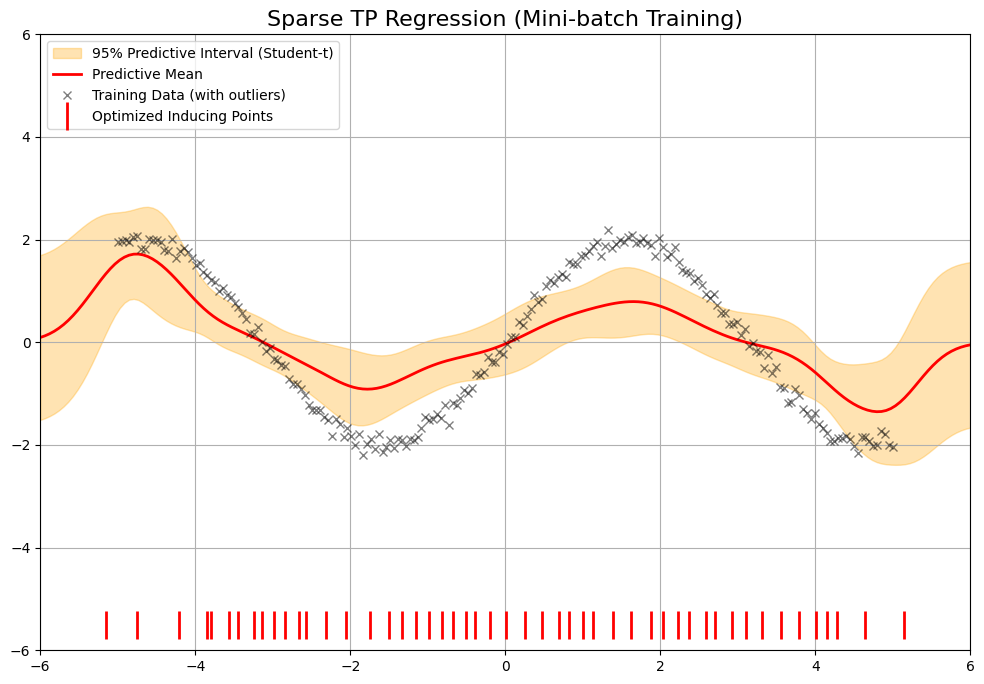

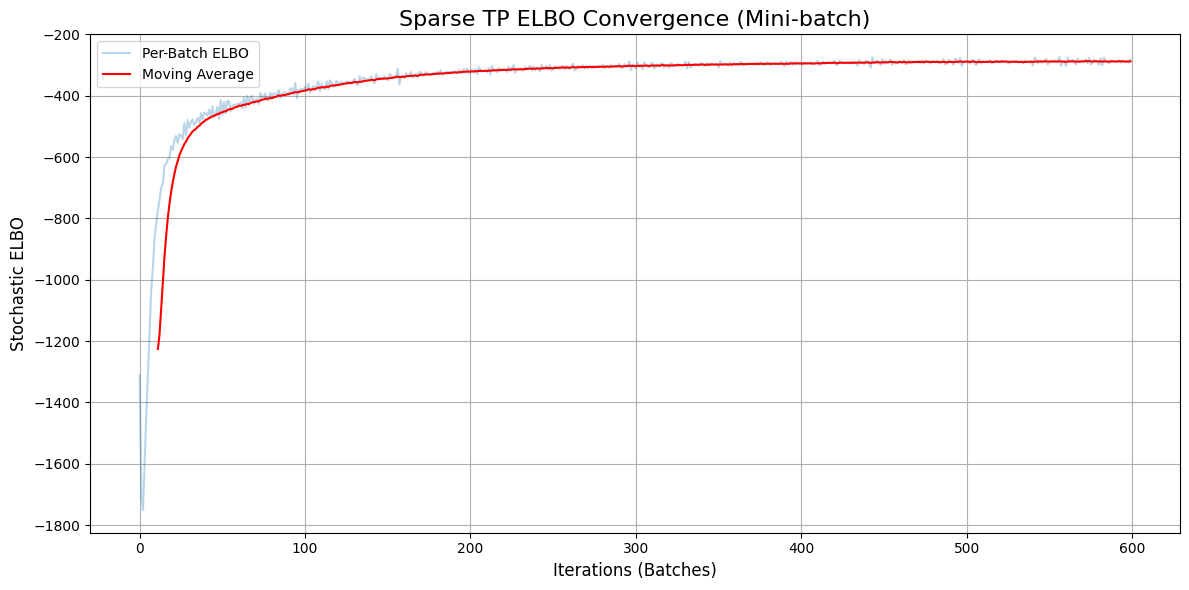

In [18]:


        
if __name__ == '__main__':

    import matplotlib.pyplot as plt
    from scipy.stats import t
    import pandas as pd

    torch.set_default_dtype(torch.float64)
    torch.manual_seed(42)

    # --- 1. 1次元データの生成 ---
    N = 200 # Increase data size for mini-batching to be more meaningful
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:20] # More outliers
    # y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    # y_train[30] = -4.0
    # y_train[70] = 5.0
    # y_train[150] = 6.0

    # --- 2. モデルのセットアップ ---
    M = 50 # Number of inducing points
    
    # Instantiate the new Mini-batch model
    model = SparseTPRTMiniBatch(
        X=X_train,
        y=y_train,
        M=M,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # --- 3. モデルの学習 ---
    elbo_history = model.fit(epochs=300, batch_size=100, cavi_max_iter=20, lr=0.01)

    # --- 4. 予測の実行 ---
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # --- 5. 回帰結果の可視化 ---
    plt.figure(figsize=(12, 8))
    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=1, alpha=0.5, label='Training Data (with outliers)')
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, mew=2, label='Optimized Inducing Points')
    plt.title('Sparse TP Regression (Mini-batch Training)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # --- 6. ELBOの履歴を可視化 ---
    plt.figure(figsize=(12, 6))
    # Plot a moving average of the ELBO to see the trend more clearly
    elbo_series = pd.Series(elbo_history)
    elbo_moving_avg = elbo_series.rolling(window=len(elbo_history) // 50).mean() # window size is num_batches
    plt.plot(elbo_history, alpha=0.3, label='Per-Batch ELBO')
    plt.plot(elbo_moving_avg, color='red', label='Moving Average')
    plt.title('Sparse TP ELBO Convergence (Mini-batch)', fontsize=16)
    plt.xlabel('Iterations (Batches)', fontsize=12)
    plt.ylabel('Stochastic ELBO', fontsize=12)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.show()

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
from torch.utils.data import DataLoader, TensorDataset
import logging
import numpy as np
from sklearn.cluster import KMeans # kmeansのために追加


class SparseTPRTMiniBatch(nn.Module):
    """
    【交互更新 SVI修正版】
    Eステップ（変分パラメータ更新）とMステップ（ハイパーパラメータ更新）を
    交互に行う確率的変分EMアルゴリズムを実装。
    """
    def __init__(self, X, y, M, nu_f=2.1, nu_e=2.1,
                 kernel_lengthscale=None, kernel_variance=1.0,
                 likelihood_sigma=1.0, device=None):
        super().__init__()

        if device is None:
            self.device = X.device
        else:
            self.device = torch.device(device)

        self.register_buffer('X_full', X.to(self.device))
        self.register_buffer('y_full', y.view(-1, 1).to(self.device))

        if self.X_full.ndim == 1: self.X_full = self.X_full.unsqueeze(1)
        if self.y_full.ndim == 1: self.y_full = self.y_full.unsqueeze(1)

        self.N, self.D = self.X_full.shape
        self.M = M
        dtype = self.X_full.dtype

        # --- ARD/Isotropic 自動対応 ---
        if kernel_lengthscale is None:
            kernel_lengthscale = torch.ones(self.D, dtype=dtype)
        else:
            kernel_lengthscale = torch.as_tensor(kernel_lengthscale, dtype=dtype)
        if kernel_lengthscale.ndim == 0:
            kernel_lengthscale = kernel_lengthscale.repeat(self.D)
        if kernel_lengthscale.shape[0] != self.D:
            raise ValueError(f"lengthscale must be a scalar or a vector of length D={self.D}")

        # --- Mステップで更新するハイパーパラメータ ---
        self.log_kernel_lengthscale = nn.Parameter(torch.log(kernel_lengthscale))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=dtype)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f, dtype=dtype)))
        self.log_nu_epsilon = nn.Parameter(torch.log(torch.tensor(nu_e, dtype=dtype)))
        self.log_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2, dtype=dtype)))
        self.Z = nn.Parameter(self._initialize_inducing_points())

        # --- Priors ---
        self.lengthscale_prior = GammaPrior(3.0, 6.0)
        self.variance_prior = GammaPrior(2.0, 0.15)
        self.sigma_sq_prior = GammaPrior(1.1, 0.05)
        self.nu_prior = LogNormalPrior(loc=1.0, scale=1.0)

        # --- Eステップで更新する変分パラメータ (Bufferとして保持) ---
        self.register_buffer('m_u', torch.zeros(self.M, 1, dtype=dtype))
        self.register_buffer('S_u', torch.eye(self.M, dtype=dtype))
        self.register_buffer('alpha_r', torch.tensor(1.0, dtype=dtype))
        self.register_buffer('beta_r', torch.tensor(1.0, dtype=dtype))

        self.to(self.device)

    def _initialize_inducing_points(self):
        """
        KMeansクラスタリングを用いて誘導点を初期化する。
        データ点数(N)が誘導点の数(M)より多い場合は、データ全体でKMeansを実行し、
        そのクラスター中心を誘導点の初期値とする。
        NがMより少ない場合は、全データ点を初期値とし、不足分は既存のデータ点から
        復元抽出し追加する。
        """
        if self.N >= self.M:
            # データ点数が誘導点数以上の場合、KMeansを実行
            X_np = self.X_full.cpu().numpy()
            # scikit-learn 1.4以降での警告を避けるため n_init='auto' を指定
            kmeans = KMeans(n_clusters=self.M, random_state=0, n_init='auto').fit(X_np)
            Z_init_np = kmeans.cluster_centers_
            Z_init = torch.from_numpy(Z_init_np)
        else:
            # データ点数が誘導点数より少ない場合
            # 全てのデータ点を使い、不足分は復元抽出で補う
            indices_all = np.arange(self.N)
            indices_resample = np.random.choice(self.N, self.M - self.N, replace=True)
            indices = np.concatenate([indices_all, indices_resample])
            Z_init = self.X_full[indices].clone()

        return Z_init.to(dtype=self.X_full.dtype, device=self.device)

    def _get_hyperparams(self):
        return {
            "nu_f": torch.exp(self.log_nu_f),
            "nu_epsilon": torch.exp(self.log_nu_epsilon),
            "sigma_sq": torch.exp(self.log_sigma_sq),
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance)
        }

    def _e_step(self, X_batch, y_batch, rho):
        """
        E-Step: ミニバッチ情報を使って変分パラメータを確率的に更新する。
        """
        with torch.no_grad():
            params = self._get_hyperparams()
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
            L_ZZ = torch.linalg.cholesky(K_ZZ)
            
            # --- 1. バッチ局所的な q(λ) を計算 ---
            # この計算には現在のグローバルな q(u), q(r) が必要
            K_XZ_batch = rbf_kernel(X_batch, self.Z, params['lengthscale'], params['variance'])
            k_ii_batch = params['variance'].expand(X_batch.shape[0])

            if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
            else: expected_r_inv = self.beta_r
            
            KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
            expected_f_mean = K_XZ_batch @ KZZ_inv_m_u
            KXZ_KZZ_inv = torch.cholesky_solve(K_XZ_batch.T, L_ZZ).T
            
            var_f_term1 = expected_r_inv * (k_ii_batch - (KXZ_KZZ_inv * K_XZ_batch).sum(dim=1))
            var_f_term2 = (KXZ_KZZ_inv @ self.S_u @ KXZ_KZZ_inv.T).diag()
            var_f = (var_f_term1 + var_f_term2).unsqueeze(1)
            
            expected_sq_error = (y_batch - expected_f_mean).pow(2) + var_f
            alpha_lambda_local = params['nu_epsilon'] / 2.0 + 0.5
            beta_lambda_local = params['nu_epsilon'] / 2.0 + (0.5 / params['sigma_sq']) * expected_sq_error
            
            # --- 2. q(u), q(r) の局所的な最適値を計算 ---
            expected_r = self.alpha_r / self.beta_r
            expected_lambda = alpha_lambda_local.squeeze() / beta_lambda_local.squeeze()
            c = expected_lambda / params['sigma_sq']
            
            # q(u) の更新式
            B = (K_XZ_batch.T * c) @ K_XZ_batch
            precision_inner = expected_r * K_ZZ + B
            L_precision_inner = torch.linalg.cholesky(precision_inner + torch.eye(self.M, dtype=K_ZZ.dtype, device=K_ZZ.device) * 1e-6)
            tmp_S = torch.cholesky_solve(K_ZZ, L_precision_inner)
            S_u_local = K_ZZ @ tmp_S
            y_term = K_XZ_batch.T @ (y_batch.squeeze() * c)
            m_u_unscaled = torch.cholesky_solve(y_term.unsqueeze(1), L_precision_inner)
            m_u_local = K_ZZ @ m_u_unscaled
            
            # q(r) の更新式
            trace_term = torch.trace(torch.cholesky_solve(S_u_local, L_ZZ))
            KZZ_inv_m_u_local = torch.cholesky_solve(m_u_local, L_ZZ)
            mean_term = m_u_local.T @ KZZ_inv_m_u_local
            expected_u_quadratic = trace_term + mean_term
            
            alpha_r_local = params['nu_f'] / 2.0 + self.M / 2.0
            beta_r_local_val = params['nu_f'] / 2.0 + 0.5 * expected_u_quadratic.squeeze()

            # 自然パラメータ上での更新を実装
            S = self.S_u.data
            m = self.m_u.data
            L = torch.linalg.cholesky(S + torch.eye(self.M, dtype=S.dtype, device=S.device) * 1e-6)
            eta_u1 = torch.cholesky_solve(m, L)
            eta_u2 = -0.5 * torch.cholesky_solve(torch.eye(self.M, dtype=S.dtype, device=S.device), L)
            eta_r1 = self.alpha_r - 1.0
            eta_r2 = -self.beta_r

            S_local = S_u_local.data
            m_local = m_u_local.data
            L_local = torch.linalg.cholesky(S_local + torch.eye(self.M, dtype=S_local.dtype, device=S_local.device) * 1e-6) 
            eta_u1_local = torch.cholesky_solve(m_local, L_local)
            eta_u2_local = -0.5 * torch.cholesky_solve(torch.eye(self.M, dtype=S_local.dtype, device=S_local.device), L_local)
            eta_r1_local = alpha_r_local - 1.0
            eta_r2_local = -beta_r_local_val

            # 更新後の自然パラメータを計算
            eta_u1_updated = (1 - rho) * eta_u1 + rho * eta_u1_local
            eta_u2_updated = (1 - rho) * eta_u2 + rho * eta_u2_local
            eta_r1_updated = (1 - rho) * eta_r1 + rho * eta_r1_local
            eta_r2_updated = (1 - rho) * eta_r2 + rho * eta_r2_local

            # 標準パラメータに変換
            S_u_local_inv = -2.0 * eta_u2_updated
            S_u_local = torch.linalg.inv(S_u_local_inv + torch.eye(self.M, dtype=S_u_local.dtype, device=S_u_local.device) * 1e-6)
            m_u_local = S_u_local @ eta_u1_updated
            alpha_r_local = eta_r1_updated + 1.0
            beta_r_local_val = -eta_r2_updated

            self.m_u.data = m_u_local
            self.S_u.data = S_u_local
            self.alpha_r.data = alpha_r_local
            self.beta_r.data = beta_r_local_val

            # self.m_u.data = (1 - rho) * self.m_u.data + rho * m_u_local.data
            # self.S_u.data = (1 - rho) * self.S_u.data + rho * S_u_local.data
            # self.alpha_r.data = (1 - rho) * self.alpha_r.data + rho * alpha_r_local.data
            # self.beta_r.data = (1 - rho) * self.beta_r.data + rho * beta_r_local_val.data

            # MステップでELBO計算に使うため、最新の局所的なλのパラメータを返す
            return alpha_lambda_local, beta_lambda_local

    def _m_step(self, optimizer, X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch):
        """
        M-Step: ELBOに基づいてハイパーパラメータを更新する。
        """
        optimizer.zero_grad()
        elbo = self._calculate_elbo(X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch)
        loss = -elbo
        loss.backward()
        optimizer.step()
        return elbo.item()
        
    def _calculate_elbo(self, X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch):
        # この関数はMステップ専用。Eステップで更新された最新の変分パラメータを使ってELBOを計算する
        B = X_batch.shape[0]
        params = self._get_hyperparams()
        
        K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
        L_ZZ = torch.linalg.cholesky(K_ZZ)
        K_XZ_batch = rbf_kernel(X_batch, self.Z, params['lengthscale'], params['variance'])
        k_ii_batch = params['variance'].expand(B)
        
        # 期待対数尤度
        expected_log_lambda = torch.digamma(alpha_lambda_batch) - torch.log(beta_lambda_batch)
        expected_lambda = alpha_lambda_batch / beta_lambda_batch
        
        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        expected_f_mean = K_XZ_batch @ KZZ_inv_m_u

        if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else: expected_r_inv = self.beta_r
        
        KXZ_KZZ_inv = torch.cholesky_solve(K_XZ_batch.T, L_ZZ).T
        var_f_term1 = expected_r_inv * (k_ii_batch - (KXZ_KZZ_inv * K_XZ_batch).sum(dim=1))
        var_f_term2 = (KXZ_KZZ_inv @ self.S_u @ KXZ_KZZ_inv.T).diag()
        var_f = (var_f_term1 + var_f_term2).unsqueeze(1)
        
        expected_sq_error = (y_batch - expected_f_mean).pow(2) + var_f
        log_lik_batch = 0.5 * torch.sum(expected_log_lambda - math.log(2 * math.pi) - torch.log(params['sigma_sq']) - \
                                  (expected_lambda / params['sigma_sq']) * expected_sq_error)
        log_lik = log_lik_batch * (self.N / B)

        # KLダイバージェンス
        p_alpha_r, p_beta_r = params['nu_f'] / 2.0, params['nu_f'] / 2.0
        kl_r = (self.alpha_r - p_alpha_r) * torch.digamma(self.alpha_r) - torch.lgamma(self.alpha_r) + torch.lgamma(p_alpha_r) + \
               p_alpha_r * (torch.log(self.beta_r) - torch.log(p_beta_r)) + self.alpha_r * (p_beta_r - self.beta_r) / self.beta_r
        
        expected_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
        expected_r = self.alpha_r / self.beta_r
        L_S = torch.linalg.cholesky(self.S_u + torch.eye(self.M, dtype=self.S_u.dtype, device=self.S_u.device) * 1e-6)
        logdet_S_u = 2 * torch.sum(torch.log(torch.diag(L_S)))
        logdet_K_ZZ = 2 * torch.sum(torch.log(torch.diag(L_ZZ)))
        trace_KZZinv_Su = torch.trace(torch.cholesky_solve(self.S_u, L_ZZ))
        m_T_KZZinv_m = self.m_u.T @ KZZ_inv_m_u
        kl_u = 0.5 * (-logdet_S_u - self.M * expected_log_r + logdet_K_ZZ + expected_r * (trace_KZZinv_Su + m_T_KZZinv_m) - self.M).squeeze()
        
        p_alpha_lambda, p_beta_lambda = params['nu_epsilon'] / 2.0, params['nu_epsilon'] / 2.0
        kl_lambda_batch = torch.sum((alpha_lambda_batch - p_alpha_lambda) * torch.digamma(alpha_lambda_batch) - \
                    torch.lgamma(alpha_lambda_batch) + torch.lgamma(p_alpha_lambda) + \
                    p_alpha_lambda * (torch.log(beta_lambda_batch) - torch.log(p_beta_lambda)) + \
                    alpha_lambda_batch * (p_beta_lambda - beta_lambda_batch) / beta_lambda_batch)
        kl_lambda = kl_lambda_batch * (self.N / B)
        
        log_prior = self.lengthscale_prior.log_prob(params['lengthscale']).sum() + \
                    self.variance_prior.log_prob(params['variance']) + \
                    self.sigma_sq_prior.log_prob(params['sigma_sq']) + \
                    self.nu_prior.log_prob(params['nu_f']) + \
                    self.nu_prior.log_prob(params['nu_epsilon'])

        return log_lik - kl_u - kl_r - kl_lambda + log_prior

    def fit(self, epochs=100, batch_size=64, lr=0.01, rho=0.05):
        # ハイパーパラメータ専用のオプティマイザ
        parameters_to_optimize = [
            self.log_nu_f, self.log_nu_epsilon, self.log_sigma_sq,
            self.log_kernel_lengthscale, self.log_kernel_variance, self.Z
        ]
        optimizer = optim.Adam(parameters_to_optimize, lr=lr)
        
        dataset = TensorDataset(self.X_full, self.y_full)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        elbo_history = []
        print(f"Starting Variational EM optimization for {epochs} epochs with batch size {batch_size}...")
        for epoch in range(epochs):
            for i, (X_batch, y_batch) in enumerate(dataloader):
                # 1. E-Step: 変分パラメータを確率的更新
                alpha_lambda_batch, beta_lambda_batch = self._e_step(X_batch, y_batch, rho=rho)
                
                # 2. M-Step: ハイパーパラメータを勾配更新
                elbo = self._m_step(optimizer, X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch)
                
                elbo_history.append(elbo)
            
            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Final Batch ELBO: {elbo:.4f}")
        
        print("\nOptimization finished.")
        return elbo_history

    def predict(self, X_test):
        X_test = X_test.to(self.device)
        with torch.no_grad():
            params = self._get_hyperparams()
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
            L_ZZ = torch.linalg.cholesky(K_ZZ)
            K_star_Z = rbf_kernel(X_test, self.Z, params['lengthscale'], params['variance'])
            k_star_star = rbf_kernel(X_test, X_test, params['lengthscale'], params['variance']).diag()

            KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
            pred_mean = K_star_Z @ KZZ_inv_m_u

            K_star_Z_K_ZZ_inv = torch.cholesky_solve(K_star_Z.T, L_ZZ, upper=False).T
            
            gp_var = k_star_star - (K_star_Z_K_ZZ_inv * K_star_Z).sum(dim=1) + \
                     (K_star_Z_K_ZZ_inv @ self.S_u @ K_star_Z_K_ZZ_inv.T).diag()
            
            pred_nu = 2 * self.alpha_r
            pred_scale_sq = (gp_var * (self.beta_r / self.alpha_r)).unsqueeze(1)
            
            return pred_mean, pred_scale_sq, pred_nu
    
    def evaluate_model(self, epochs=100, batch_size=64, lr=0.01, rho=0.05,
                       X_test=None, y_test=None, eval_interval=10,
                       result_path=None):

        parameters_to_optimize = [
            self.log_nu_f, self.log_nu_epsilon, self.log_sigma_sq,
            self.log_kernel_lengthscale, self.log_kernel_variance, self.Z
        ]
        optimizer = optim.Adam(parameters_to_optimize, lr=lr)

        dataset = TensorDataset(self.X_full, self.y_full)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

        can_evaluate = X_test is not None and y_test is not None and result_path is not None
        if can_evaluate:
            X_test_dev, y_test_dev = X_test.to(self.device), y_test.to(self.device)
            if not result_path.exists():
                result_path.parent.mkdir(parents=True, exist_ok=True)
                with open(result_path, 'w') as f:
                    f.write("epoch,rmse,elbo\n")

        print(f"Starting Variational EM optimization for {epochs} epochs with batch size {batch_size}...")
        for epoch in range(epochs):
            elbo_val = 0.0
            for i, (X_batch, y_batch) in enumerate(dataloader):
                # 1. E-Step
                alpha_lambda_batch, beta_lambda_batch = self._e_step(X_batch, y_batch, rho=rho)
                
                # 2. M-Step
                elbo_val = self._m_step(optimizer, X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch)

            if can_evaluate and (epoch + 1) % eval_interval == 0:
                with torch.no_grad():
                    pred_mean, _, _ = self.predict(X_test_dev)
                    rmse = torch.sqrt(torch.mean((y_test_dev.view(-1) - pred_mean.view(-1))**2)).item()
                
                logging.info(f"Epoch {epoch+1}/{epochs}, Final Batch ELBO: {elbo_val:.4f}, Test RMSE: {rmse:.4f}")
                
                with open(result_path, 'a') as f:
                    f.write(f"{epoch+1},{rmse},{elbo_val}\n")
        
        if can_evaluate:
             with torch.no_grad():
                pred_mean, _, _ = self.predict(X_test_dev)
                rmse = torch.sqrt(torch.mean((y_test_dev.view(-1) - pred_mean.view(-1))**2)).item()
             
             if epochs > 0 and epochs % eval_interval != 0:
                 with open(result_path, 'a') as f:
                    f.write(f"{epochs},{rmse},{elbo_val}\n")
        
        print("\nOptimization finished.")

Starting Variational EM optimization for 100 epochs with batch size 50...


Epoch 10/100, Final Batch ELBO: -306.8085
Epoch 20/100, Final Batch ELBO: -218.0429
Epoch 30/100, Final Batch ELBO: -245.9028
Epoch 40/100, Final Batch ELBO: -209.5710
Epoch 50/100, Final Batch ELBO: -188.2394
Epoch 60/100, Final Batch ELBO: -158.8655
Epoch 70/100, Final Batch ELBO: -149.0210
Epoch 80/100, Final Batch ELBO: -171.0727
Epoch 90/100, Final Batch ELBO: -202.6757
Epoch 100/100, Final Batch ELBO: -119.7296

Optimization finished.


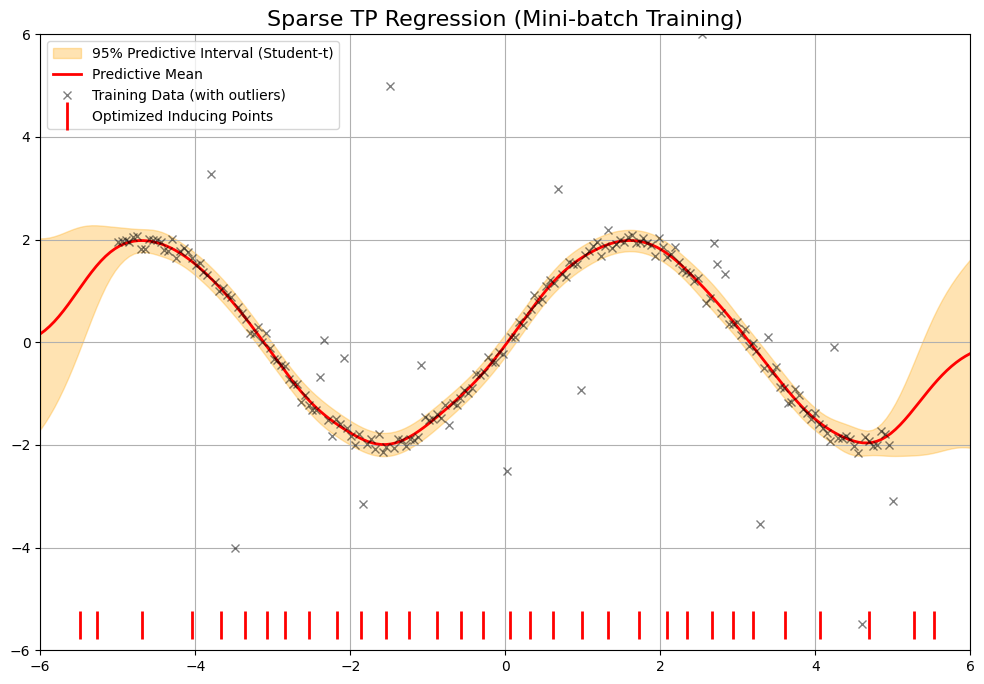

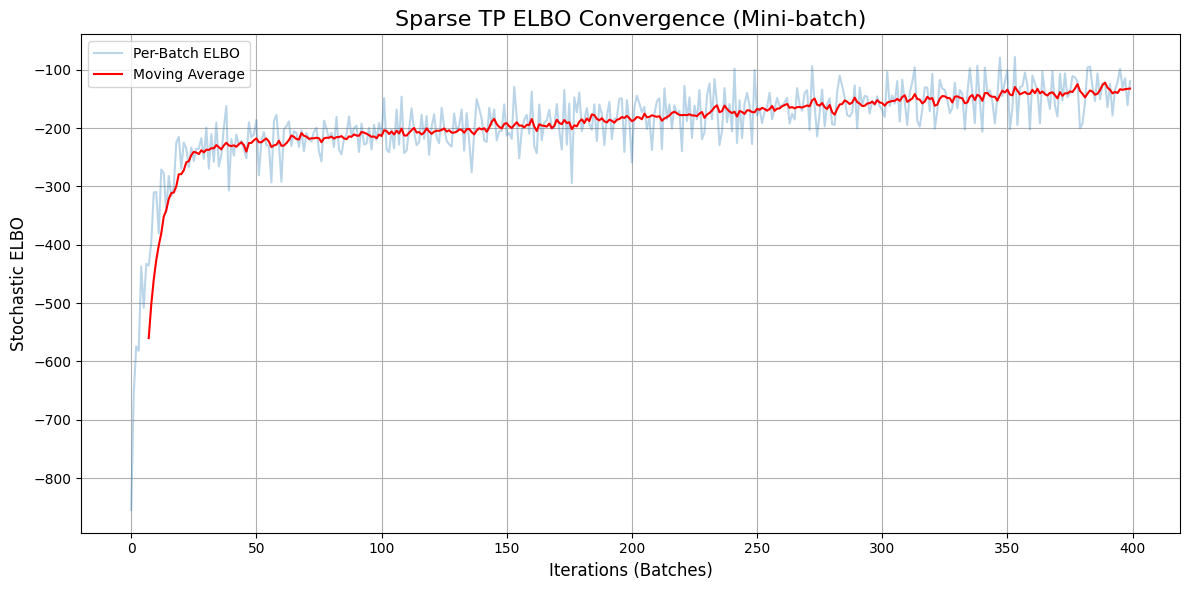

In [22]:


        
if __name__ == '__main__':

    import matplotlib.pyplot as plt
    from scipy.stats import t
    import pandas as pd

    torch.set_default_dtype(torch.float64)
    torch.manual_seed(42)

    # --- 1. 1次元データの生成 ---
    N = 200 # Increase data size for mini-batching to be more meaningful
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:20] # More outliers
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[30] = -4.0
    y_train[70] = 5.0
    y_train[150] = 6.0

    # --- 2. モデルのセットアップ ---
    M = 32 # Number of inducing points
    
    # Instantiate the new Mini-batch model
    model = SparseTPRTMiniBatch(
        X=X_train,
        y=y_train,
        M=M,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # --- 3. モデルの学習 ---
    elbo_history = model.fit(epochs=100, batch_size=50, lr=0.01)

    # --- 4. 予測の実行 ---
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # --- 5. 回帰結果の可視化 ---
    plt.figure(figsize=(12, 8))
    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=1, alpha=0.5, label='Training Data (with outliers)')
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, mew=2, label='Optimized Inducing Points')
    plt.title('Sparse TP Regression (Mini-batch Training)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # --- 6. ELBOの履歴を可視化 ---
    plt.figure(figsize=(12, 6))
    # Plot a moving average of the ELBO to see the trend more clearly
    elbo_series = pd.Series(elbo_history)
    elbo_moving_avg = elbo_series.rolling(window=len(elbo_history) // 50).mean() # window size is num_batches
    plt.plot(elbo_history, alpha=0.3, label='Per-Batch ELBO')
    plt.plot(elbo_moving_avg, color='red', label='Moving Average')
    plt.title('Sparse TP ELBO Convergence (Mini-batch)', fontsize=16)
    plt.xlabel('Iterations (Batches)', fontsize=12)
    plt.ylabel('Stochastic ELBO', fontsize=12)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.show()

Starting Variational EM optimization for 30 epochs with batch size 50...
Epoch 10/30, Final Batch ELBO: -306.8085
Epoch 20/30, Final Batch ELBO: -218.0429
Epoch 30/30, Final Batch ELBO: -245.9028

Optimization finished.


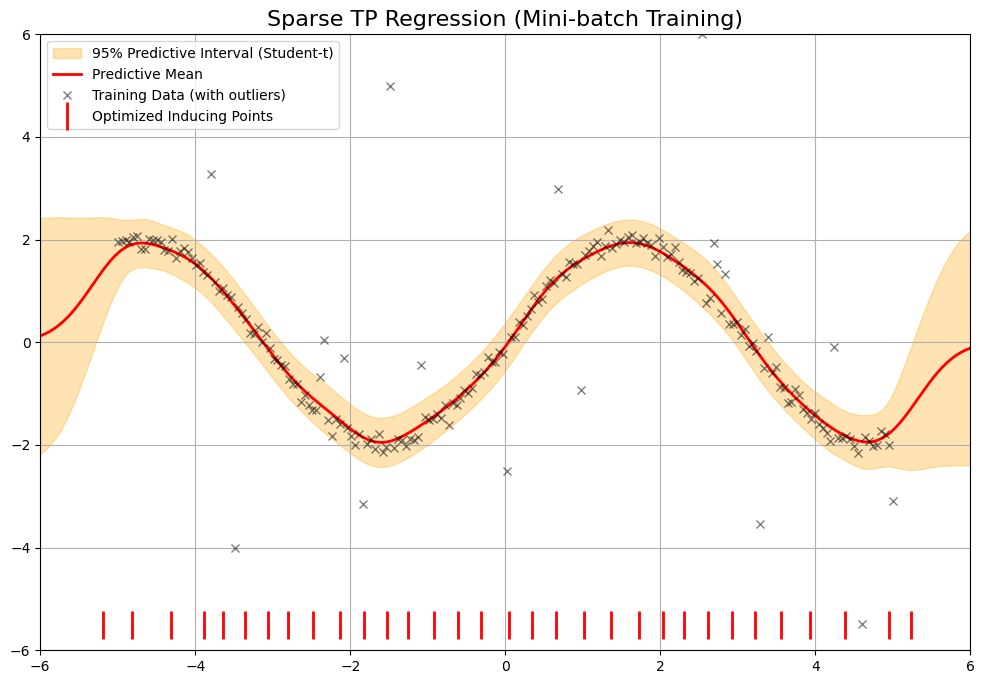

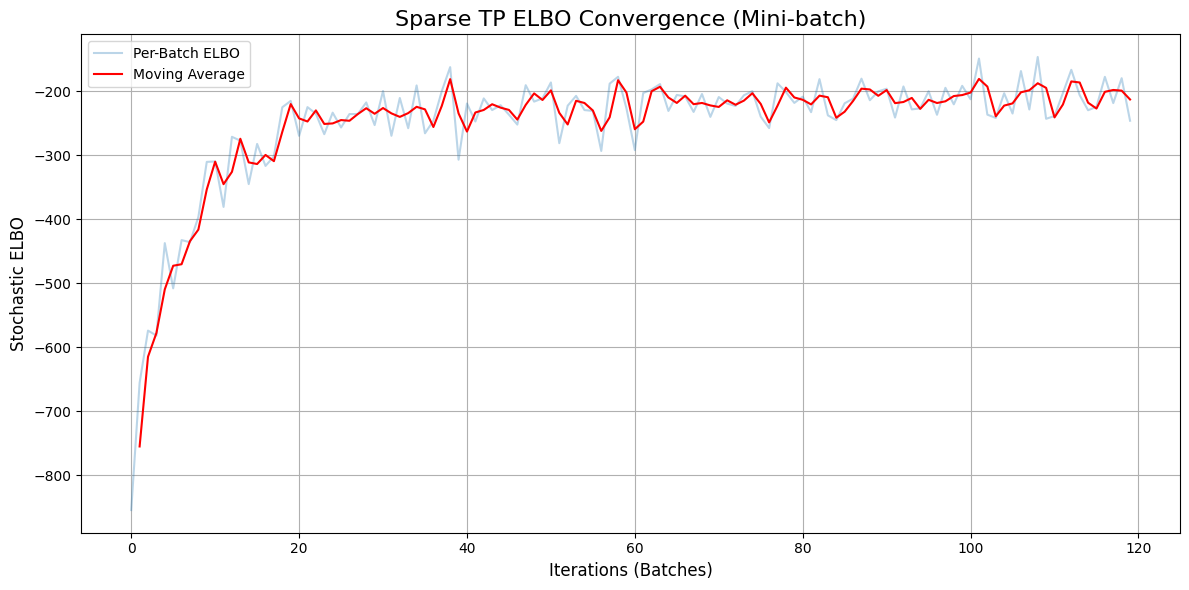

In [23]:


        
if __name__ == '__main__':

    import matplotlib.pyplot as plt
    from scipy.stats import t
    import pandas as pd

    torch.set_default_dtype(torch.float64)
    torch.manual_seed(42)

    # --- 1. 1次元データの生成 ---
    N = 200 # Increase data size for mini-batching to be more meaningful
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:20] # More outliers
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[30] = -4.0
    y_train[70] = 5.0
    y_train[150] = 6.0

    # --- 2. モデルのセットアップ ---
    M = 32 # Number of inducing points
    
    # Instantiate the new Mini-batch model
    model = SparseTPRTMiniBatch(
        X=X_train,
        y=y_train,
        M=M,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # --- 3. モデルの学習 ---
    elbo_history = model.fit(epochs=30, batch_size=50, lr=0.01)

    # --- 4. 予測の実行 ---
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # --- 5. 回帰結果の可視化 ---
    plt.figure(figsize=(12, 8))
    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=1, alpha=0.5, label='Training Data (with outliers)')
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, mew=2, label='Optimized Inducing Points')
    plt.title('Sparse TP Regression (Mini-batch Training)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # --- 6. ELBOの履歴を可視化 ---
    plt.figure(figsize=(12, 6))
    # Plot a moving average of the ELBO to see the trend more clearly
    elbo_series = pd.Series(elbo_history)
    elbo_moving_avg = elbo_series.rolling(window=len(elbo_history) // 50).mean() # window size is num_batches
    plt.plot(elbo_history, alpha=0.3, label='Per-Batch ELBO')
    plt.plot(elbo_moving_avg, color='red', label='Moving Average')
    plt.title('Sparse TP ELBO Convergence (Mini-batch)', fontsize=16)
    plt.xlabel('Iterations (Batches)', fontsize=12)
    plt.ylabel('Stochastic ELBO', fontsize=12)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.show()

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
from torch.utils.data import DataLoader, TensorDataset
import logging
from pathlib import Path
import numpy as np
from sklearn.cluster import KMeans

# Helper functions remain outside the class
def rbf_kernel(X1, X2, lengthscale, variance):
    X1_scaled = X1 / lengthscale
    X2_scaled = X2 / lengthscale
    sq_dist = torch.cdist(X1_scaled, X2_scaled, p=2).pow(2)
    return variance * torch.exp(-0.5 * sq_dist)

class GammaPrior(torch.distributions.Gamma):
    def __init__(self, concentration, rate):
        super().__init__(concentration, rate)
    def log_prob(self, value):
        return super().log_prob(value.clamp(min=1e-8))

class LogNormalPrior(torch.distributions.LogNormal):
    def __init__(self, loc, scale):
        super().__init__(loc, scale)
    def log_prob(self, value):
        return super().log_prob(value.clamp(min=1e-8))


class SparseTPRTMiniBatch(nn.Module):
    """
    【交互更新 SVI修正版】- Corrected and Efficient Version
    This version restores the natural parameter update logic while retaining
    performance optimizations.
    """
    def __init__(self, X, y, M, nu_f=2.1, nu_e=2.1,
                 kernel_lengthscale=None, kernel_variance=1.0,
                 likelihood_sigma=1.0, device=None):
        super().__init__()

        if device is None:
            self.device = X.device if isinstance(X, torch.Tensor) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)

        self.register_buffer('X_full', X.to(self.device))
        self.register_buffer('y_full', y.view(-1, 1).to(self.device))

        if self.X_full.ndim == 1: self.X_full = self.X_full.unsqueeze(1)
        if self.y_full.ndim == 1: self.y_full = self.y_full.unsqueeze(1)

        self.N, self.D = self.X_full.shape
        self.M = M
        dtype = self.X_full.dtype

        if kernel_lengthscale is None:
            kernel_lengthscale = torch.ones(self.D, dtype=dtype)
        else:
            kernel_lengthscale = torch.as_tensor(kernel_lengthscale, dtype=dtype)
        if kernel_lengthscale.ndim == 0:
            kernel_lengthscale = kernel_lengthscale.repeat(self.D)
        if kernel_lengthscale.shape[0] != self.D:
            raise ValueError(f"lengthscale must be a scalar or a vector of length D={self.D}")

        self.log_kernel_lengthscale = nn.Parameter(torch.log(kernel_lengthscale))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=dtype)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f, dtype=dtype)))
        self.log_nu_epsilon = nn.Parameter(torch.log(torch.tensor(nu_e, dtype=dtype)))
        self.log_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2, dtype=dtype)))
        self.Z = nn.Parameter(self._initialize_inducing_points())

        self.lengthscale_prior = GammaPrior(3.0, 6.0)
        self.variance_prior = GammaPrior(2.0, 0.15)
        self.sigma_sq_prior = GammaPrior(1.1, 0.05)
        self.nu_prior = LogNormalPrior(loc=1.0, scale=1.0)

        self.register_buffer('m_u', torch.zeros(self.M, 1, dtype=dtype))
        self.register_buffer('S_u', torch.eye(self.M, dtype=dtype))
        self.register_buffer('alpha_r', torch.tensor(1.0, dtype=dtype))
        self.register_buffer('beta_r', torch.tensor(1.0, dtype=dtype))

        self.to(self.device)

    def _initialize_inducing_points(self):
        if self.N >= self.M:
            X_np = self.X_full.cpu().numpy()
            kmeans = KMeans(n_clusters=self.M, random_state=0, n_init='auto').fit(X_np)
            Z_init = torch.from_numpy(kmeans.cluster_centers_)
        else:
            indices = np.random.choice(self.N, self.M, replace=True)
            Z_init = self.X_full[indices].clone()
        return Z_init.to(dtype=self.X_full.dtype, device=self.device)

    def _get_hyperparams(self):
        return {
            "nu_f": torch.exp(self.log_nu_f), "nu_epsilon": torch.exp(self.log_nu_epsilon),
            "sigma_sq": torch.exp(self.log_sigma_sq), "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance)
        }

    def _compute_common_terms(self, X_batch, params):
        K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
        L_ZZ = torch.linalg.cholesky(K_ZZ)
        K_XZ_batch = rbf_kernel(X_batch, self.Z, params['lengthscale'], params['variance'])
        KXZ_KZZ_inv = torch.linalg.solve(K_ZZ, K_XZ_batch.T).T
        return K_ZZ, L_ZZ, K_XZ_batch, KXZ_KZZ_inv

    def _e_step(self, X_batch, y_batch, rho, common_terms):
        with torch.no_grad():
            params = self._get_hyperparams()
            K_ZZ, L_ZZ, K_XZ_batch, KXZ_KZZ_inv = common_terms

            k_ii_batch = params['variance'].expand(X_batch.shape[0])

            expected_r_inv = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r

            KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
            expected_f_mean = K_XZ_batch @ KZZ_inv_m_u

            var_f_term1 = expected_r_inv * (k_ii_batch - (KXZ_KZZ_inv * K_XZ_batch).sum(dim=1))
            var_f_term2 = (KXZ_KZZ_inv @ self.S_u @ KXZ_KZZ_inv.T).diag()
            var_f = (var_f_term1 + var_f_term2).unsqueeze(1)

            expected_sq_error = (y_batch - expected_f_mean).pow(2) + var_f
            alpha_lambda_local = params['nu_epsilon'] / 2.0 + 0.5
            beta_lambda_local = params['nu_epsilon'] / 2.0 + (0.5 / params['sigma_sq']) * expected_sq_error

            expected_r = self.alpha_r / self.beta_r
            expected_lambda = alpha_lambda_local.squeeze() / beta_lambda_local.squeeze()
            c = expected_lambda / params['sigma_sq']

            B = (K_XZ_batch.T * c) @ K_XZ_batch
            precision_inner = expected_r * K_ZZ + B
            L_precision_inner = torch.linalg.cholesky(precision_inner + torch.eye(self.M, device=K_ZZ.device) * 1e-6)
            
            S_u_local = K_ZZ @ torch.cholesky_solve(K_ZZ, L_precision_inner)
            y_term = K_XZ_batch.T @ (y_batch.squeeze() * c)
            m_u_local = K_ZZ @ torch.cholesky_solve(y_term.unsqueeze(1), L_precision_inner)
            
            trace_term = torch.trace(torch.cholesky_solve(S_u_local, L_ZZ))
            KZZ_inv_m_u_local = torch.cholesky_solve(m_u_local, L_ZZ)
            mean_term = m_u_local.T @ KZZ_inv_m_u_local
            expected_u_quadratic = trace_term + mean_term

            alpha_r_local = params['nu_f'] / 2.0 + self.M / 2.0
            beta_r_local_val = params['nu_f'] / 2.0 + 0.5 * expected_u_quadratic.squeeze()

            ## <<< LOGIC RESTORED: Perform update in natural parameter space >>> ##
            # 1. Convert global variational parameters to natural parameters
            S_inv = torch.linalg.inv(self.S_u + torch.eye(self.M, dtype=self.S_u.dtype, device=self.S_u.device) * 1e-6)
            eta_u1_global = S_inv @ self.m_u
            eta_u2_global = -0.5 * S_inv
            eta_r1_global = self.alpha_r - 1.0
            eta_r2_global = -self.beta_r

            # 2. Convert local variational parameters to natural parameters
            S_local_inv = torch.linalg.inv(S_u_local + torch.eye(self.M, dtype=S_u_local.dtype, device=S_u_local.device) * 1e-6)
            eta_u1_local = S_local_inv @ m_u_local
            eta_u2_local = -0.5 * S_local_inv
            eta_r1_local = alpha_r_local - 1.0
            eta_r2_local = -beta_r_local_val

            # 3. Linearly interpolate in natural parameter space
            eta_u1_updated = (1 - rho) * eta_u1_global + rho * eta_u1_local
            eta_u2_updated = (1 - rho) * eta_u2_global + rho * eta_u2_local
            eta_r1_updated = (1 - rho) * eta_r1_global + rho * eta_r1_local
            eta_r2_updated = (1 - rho) * eta_r2_global + rho * eta_r2_local
            
            # 4. Convert back to standard parameters and update buffers
            S_u_updated = torch.linalg.inv(-2.0 * eta_u2_updated + torch.eye(self.M, dtype=S_u_local.dtype, device=S_u_local.device) * 1e-6)
            m_u_updated = S_u_updated @ eta_u1_updated
            alpha_r_updated = eta_r1_updated + 1.0
            beta_r_updated = -eta_r2_updated

            self.m_u.data = m_u_updated
            self.S_u.data = S_u_updated
            self.alpha_r.data = alpha_r_updated
            self.beta_r.data = beta_r_updated
            ## <<< END OF RESTORED LOGIC >>> ##

            return alpha_lambda_local, beta_lambda_local

    def _m_step_and_elbo(self, optimizer, X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch, common_terms):
        optimizer.zero_grad()
        elbo = self._calculate_elbo(X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch, common_terms)
        loss = -elbo
        loss.backward()
        # Add gradient clipping for stability
        nn.utils.clip_grad_norm_(self.parameters(), max_norm=10.0)
        optimizer.step()
        return elbo.item()

    def _calculate_elbo(self, X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch, common_terms):
        B = X_batch.shape[0]
        params = self._get_hyperparams()
        
        K_ZZ, L_ZZ, K_XZ_batch, KXZ_KZZ_inv = common_terms
        k_ii_batch = params['variance'].expand(B)

        expected_log_lambda = torch.digamma(alpha_lambda_batch) - torch.log(beta_lambda_batch)
        expected_lambda = alpha_lambda_batch / beta_lambda_batch
        
        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        expected_f_mean = K_XZ_batch @ KZZ_inv_m_u

        expected_r_inv = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
        
        var_f_term1 = expected_r_inv * (k_ii_batch - (KXZ_KZZ_inv * K_XZ_batch).sum(dim=1))
        var_f_term2 = (KXZ_KZZ_inv @ self.S_u @ KXZ_KZZ_inv.T).diag()
        var_f = (var_f_term1 + var_f_term2).unsqueeze(1)
        
        expected_sq_error = (y_batch - expected_f_mean).pow(2) + var_f
        log_lik_batch = 0.5 * torch.sum(expected_log_lambda - math.log(2 * math.pi) - torch.log(params['sigma_sq']) - \
                                  (expected_lambda / params['sigma_sq']) * expected_sq_error)
        log_lik = log_lik_batch * (self.N / B)

        p_alpha_r, p_beta_r = params['nu_f'] / 2.0, params['nu_f'] / 2.0
        kl_r = (self.alpha_r - p_alpha_r) * torch.digamma(self.alpha_r) - torch.lgamma(self.alpha_r) + torch.lgamma(p_alpha_r) + \
               p_alpha_r * (torch.log(self.beta_r) - torch.log(p_beta_r)) + self.alpha_r * (p_beta_r - self.beta_r) / self.beta_r

        expected_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
        expected_r = self.alpha_r / self.beta_r
        
        L_S = torch.linalg.cholesky(self.S_u + torch.eye(self.M, dtype=self.S_u.dtype, device=self.S_u.device) * 1e-6)
        logdet_S_u = 2 * torch.sum(torch.log(torch.diag(L_S)))
        logdet_K_ZZ = 2 * torch.sum(torch.log(torch.diag(L_ZZ)))
        
        trace_KZZinv_Su = torch.trace(torch.cholesky_solve(self.S_u, L_ZZ))
        m_T_KZZinv_m = self.m_u.T @ KZZ_inv_m_u
        kl_u = 0.5 * (-logdet_S_u - self.M * expected_log_r + logdet_K_ZZ + expected_r * (trace_KZZinv_Su + m_T_KZZinv_m) - self.M).squeeze()
        
        p_alpha_lambda, p_beta_lambda = params['nu_epsilon'] / 2.0, params['nu_epsilon'] / 2.0
        kl_lambda_batch = torch.sum((alpha_lambda_batch - p_alpha_lambda) * torch.digamma(alpha_lambda_batch) - \
                    torch.lgamma(alpha_lambda_batch) + torch.lgamma(p_alpha_lambda) + \
                    p_alpha_lambda * (torch.log(beta_lambda_batch) - torch.log(p_beta_lambda)) + \
                    alpha_lambda_batch * (p_beta_lambda - beta_lambda_batch) / beta_lambda_batch)
        kl_lambda = kl_lambda_batch * (self.N / B)
        
        log_prior = self.lengthscale_prior.log_prob(params['lengthscale']).sum() + \
                    self.variance_prior.log_prob(params['variance']) + \
                    self.sigma_sq_prior.log_prob(params['sigma_sq']) + \
                    self.nu_prior.log_prob(params['nu_f']) + \
                    self.nu_prior.log_prob(params['nu_epsilon'])

        return log_lik - kl_u - kl_r - kl_lambda + log_prior

    def fit(self, epochs=100, batch_size=64, lr=0.01, rho=0.05,
            X_test=None, y_test=None, eval_interval=10, result_path=None):
        parameters_to_optimize = [
            self.log_nu_f, self.log_nu_epsilon, self.log_sigma_sq,
            self.log_kernel_lengthscale, self.log_kernel_variance, self.Z
        ]
        optimizer = optim.Adam(parameters_to_optimize, lr=lr)
        dataset = TensorDataset(self.X_full, self.y_full)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        elbo_history = []
        
        can_evaluate = X_test is not None and y_test is not None
        if can_evaluate and result_path:
            result_path = Path(result_path)
            result_path.parent.mkdir(parents=True, exist_ok=True)
            with open(result_path, 'w') as f: f.write("epoch,rmse,elbo\n")

        print(f"Starting Variational EM optimization for {epochs} epochs...")
        for epoch in range(epochs):
            elbo_val = 0.0
            for X_batch, y_batch in dataloader:
                params = self._get_hyperparams()
                common_terms = self._compute_common_terms(X_batch, params)
                alpha_lambda, beta_lambda = self._e_step(X_batch, y_batch, rho, common_terms)
                elbo_val = self._m_step_and_elbo(optimizer, X_batch, y_batch, alpha_lambda, beta_lambda, common_terms)
                elbo_history.append(elbo_val)
            
            if can_evaluate and (epoch + 1) % eval_interval == 0:
                with torch.no_grad():
                    pred_mean, _, _ = self.predict(X_test)
                    rmse = torch.sqrt(torch.mean((y_test.view(-1) - pred_mean.view(-1))**2)).item()
                
                log_msg = f"Epoch {epoch+1}/{epochs}, ELBO: {elbo_val:.4f}, Test RMSE: {rmse:.4f}"
                print(log_msg)
                if result_path:
                    with open(result_path, 'a') as f: f.write(f"{epoch+1},{rmse},{elbo_val}\n")
            elif (epoch + 1) % 10 == 0:
                 print(f"Epoch {epoch+1}/{epochs}, Final Batch ELBO: {elbo_val:.4f}")

        print("\nOptimization finished.")
        return elbo_history

    def predict(self, X_test):
        X_test_dev = X_test.to(self.device)
        with torch.no_grad():
            params = self._get_hyperparams()
            k_star_star = rbf_kernel(X_test_dev, X_test_dev, params['lengthscale'], params['variance']).diag()

            _, L_ZZ, K_star_Z, K_star_Z_K_ZZ_inv = self._compute_common_terms(X_test_dev, params)
            
            KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
            pred_mean = K_star_Z @ KZZ_inv_m_u
            
            gp_var = k_star_star - (K_star_Z_K_ZZ_inv * K_star_Z).sum(dim=1) + \
                     (K_star_Z_K_ZZ_inv @ self.S_u @ K_star_Z_K_ZZ_inv.T).diag()
            
            pred_nu = 2 * self.alpha_r
            pred_scale_sq = (gp_var * (self.beta_r / self.alpha_r)).unsqueeze(1)
            
            return pred_mean, pred_scale_sq, pred_nu

Starting Variational EM optimization for 100 epochs...


Epoch 10/100, Final Batch ELBO: -307.6483
Epoch 20/100, Final Batch ELBO: -213.8701
Epoch 30/100, Final Batch ELBO: -231.8866
Epoch 40/100, Final Batch ELBO: -202.3815
Epoch 50/100, Final Batch ELBO: -175.6887
Epoch 60/100, Final Batch ELBO: -147.8259
Epoch 70/100, Final Batch ELBO: -146.2570
Epoch 80/100, Final Batch ELBO: -171.4409
Epoch 90/100, Final Batch ELBO: -206.1418
Epoch 100/100, Final Batch ELBO: -133.6386

Optimization finished.


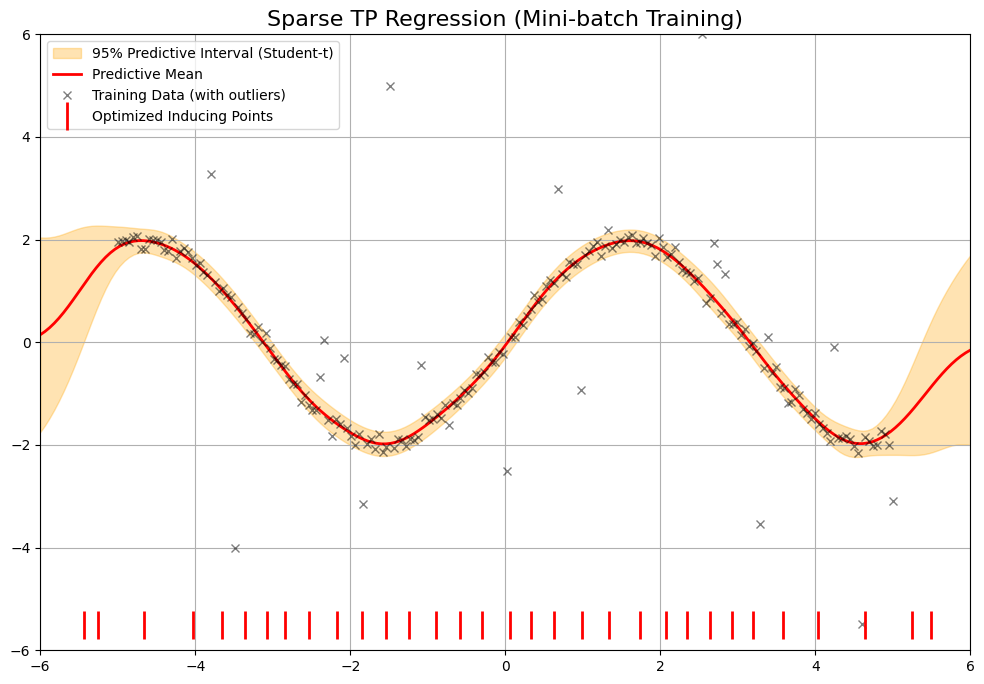

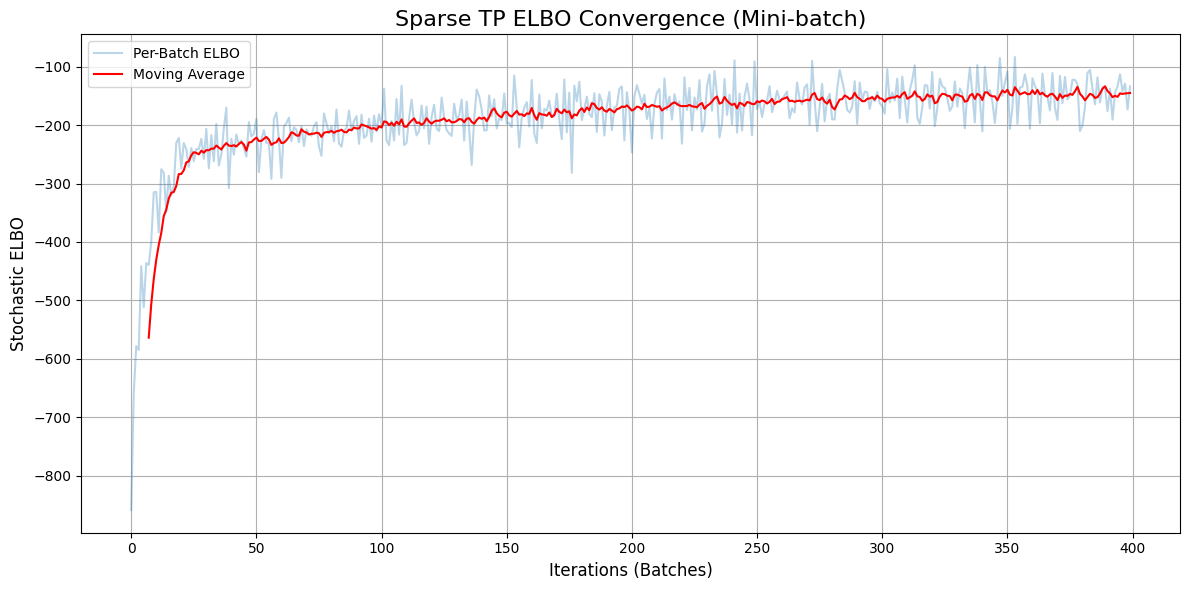

In [28]:


        
if __name__ == '__main__':

    import matplotlib.pyplot as plt
    from scipy.stats import t
    import pandas as pd

    torch.set_default_dtype(torch.float64)
    torch.manual_seed(42)

    # --- 1. 1次元データの生成 ---
    N = 200 # Increase data size for mini-batching to be more meaningful
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:20] # More outliers
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[30] = -4.0
    y_train[70] = 5.0
    y_train[150] = 6.0

    # --- 2. モデルのセットアップ ---
    M = 32 # Number of inducing points
    
    # Instantiate the new Mini-batch model
    model = SparseTPRTMiniBatch(
        X=X_train,
        y=y_train,
        M=M,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # --- 3. モデルの学習 ---
    elbo_history = model.fit(epochs=100, batch_size=50, lr=0.01)

    # --- 4. 予測の実行 ---
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # --- 5. 回帰結果の可視化 ---
    plt.figure(figsize=(12, 8))
    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=1, alpha=0.5, label='Training Data (with outliers)')
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, mew=2, label='Optimized Inducing Points')
    plt.title('Sparse TP Regression (Mini-batch Training)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # --- 6. ELBOの履歴を可視化 ---
    plt.figure(figsize=(12, 6))
    # Plot a moving average of the ELBO to see the trend more clearly
    elbo_series = pd.Series(elbo_history)
    elbo_moving_avg = elbo_series.rolling(window=len(elbo_history) // 50).mean() # window size is num_batches
    plt.plot(elbo_history, alpha=0.3, label='Per-Batch ELBO')
    plt.plot(elbo_moving_avg, color='red', label='Moving Average')
    plt.title('Sparse TP ELBO Convergence (Mini-batch)', fontsize=16)
    plt.xlabel('Iterations (Batches)', fontsize=12)
    plt.ylabel('Stochastic ELBO', fontsize=12)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.show()